In [190]:
# Test_earthquake_classifier_week4
## 1. Import Necessary Libraries
## 2. Load and Explore the dataset
# 2.1 Explore the target variable: to know which feature should be kept or drop
## 3. Splitting Data into Training and Test Sets
## 4. Data Preprocessing
## 5. Model Fitting, Test, Evaluation  
# 6. Evaluation models

## 1. Import Necessary Libraries

In [191]:
# Data manipulation and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
%matplotlib inline

# Scikit-learn: Model training, preprocessing, and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

# Machine learning models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


## 2. Load and Explore data

In [192]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2024\\2024 Python Data Science\\Machine Learning\\earthquake_data.csv")
print(df.head())
print(df.info())

                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                  location continent          

Earthquake dataset

Datasets contain records of 782 earthquakes from 1/1/2001 to 1/1/2023. The meaning of all columns is as follows:

title: title name given to the earthquake

magnitude: The magnitude of the earthquake

date_time: date and time

cdi: The maximum reported intensity for the event range

mmi: The maximum estimated instrumental intensity for the event

alert: The alert level - “green”, “yellow”, “orange”, and “red”

tsunami: "1" for events in oceanic regions and "0" otherwise

sig: A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined on a number of factors, including: magnitude, maximum MMI, felt reports, and estimated impact

net: The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.

nst: The total number of seismic stations used to determine earthquake location.

dmin: Horizontal distance from the epicenter to the nearest station

gap: The largest azimuthal gap between azimuthally adjacent stations (in degrees). In general, the smaller this number, the more reliable is the calculated horizontal position of the earthquake. Earthquake locations in which the azimuthal gap exceeds 180 degrees typically have large location and depth uncertainties

magType: The method or algorithm used to calculate the preferred magnitude for the event

depth: The depth where the earthquake begins to rupture

latitude / longitude: coordinate system by means of which the position or location of any place on Earth's surface can be determined and described

location: location within the country

continent: continent of the earthquake hit country

country: affected country

In [193]:
# # ydata-profiling generates an in-depth report, helping us quickly understand, data distributions, and correlations.
# profile = ProfileReport(df, title = "Earthquake_dataset_Report", explorative=True)
# profile.to_file("report_Earthquake_dataset.html")
# print(os.path.abspath("report_Earthquake_dataset.html"))

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


<Axes: >

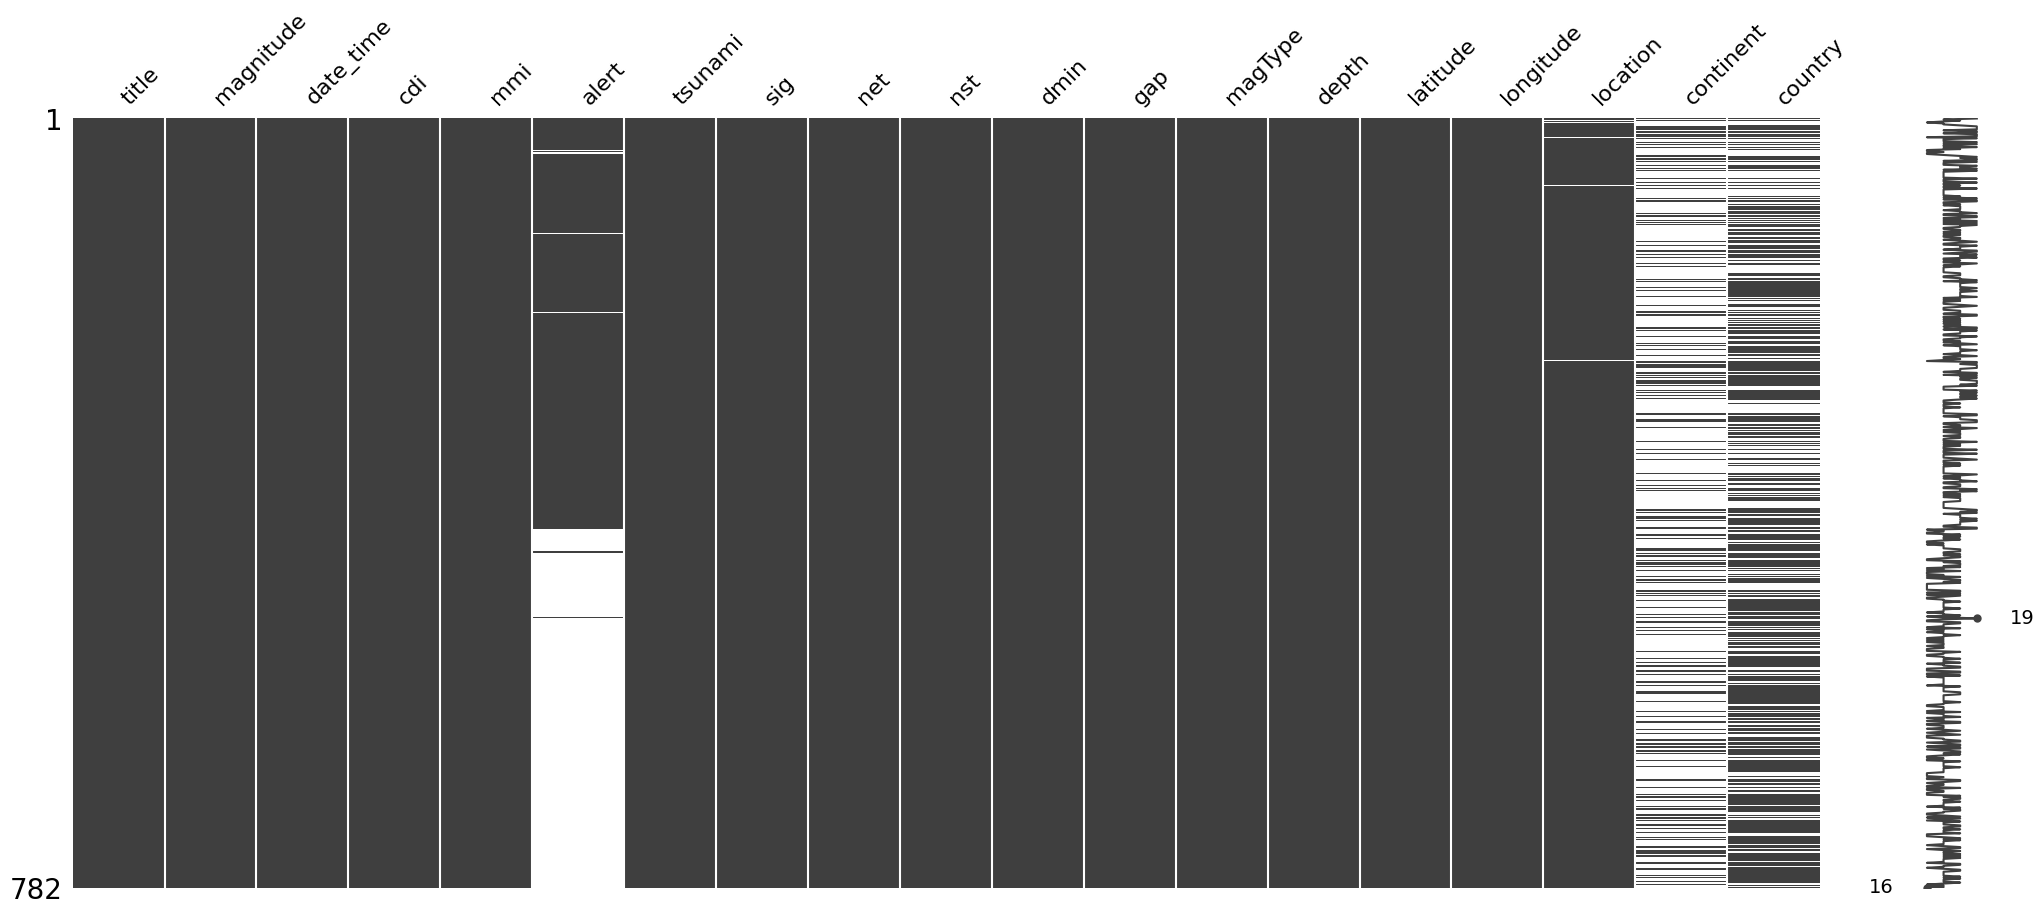

In [169]:
# Identifying missing values helps ensure data quality and informs decisions on the imputation. 
missing_counts = df.isnull().sum() # missing_counts=df.isna().sum()
print(missing_counts)
msno.matrix(df)

In [94]:
# Check for duplicates
print(df.duplicated().sum())

0


In [95]:
# Check for 0 values in the dataset
print((df == 0).sum())

title          0
magnitude      0
date_time      0
cdi          212
mmi            0
alert          0
tsunami      478
sig            0
net            0
nst          365
dmin         405
gap           70
magType        0
depth          0
latitude       0
longitude      0
location       0
continent      0
country        0
dtype: int64


In [96]:
# Check columns with exactly 2 unique values
print("Columns with exactly 2 unique values:")
for col in df.columns:
    unique_values = df[col].dropna().unique()  # Get unique non-null values
    if len(unique_values) == 2:
        print(f"Column '{col}':")
        print(df[col].value_counts())

Columns with exactly 2 unique values:
Column 'tsunami':
tsunami
0    478
1    304
Name: count, dtype: int64


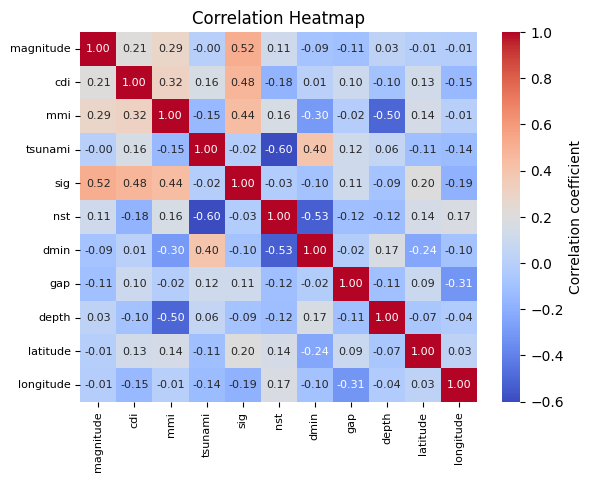

In [97]:
# correlation matrix helps identify relationships between features, how they interact, and avoid multicollinearity.
numeric_data = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

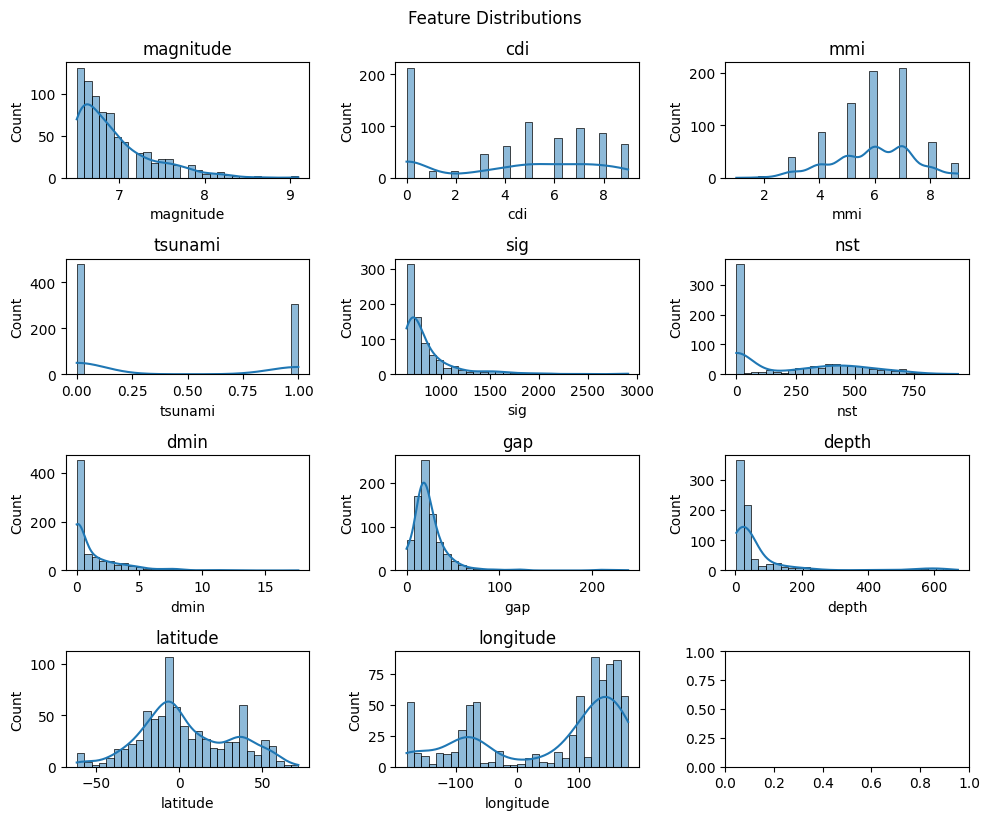

In [98]:
# Feature Distributions: Visualize numeric features to understand their distribution
# Helps identify skewness, outliers, and check normality for preprocessing decisions.
numeric_columns = df.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(4, 3, figsize=(10, 8))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, kde=True, bins=30, ax=axes[i])  
    axes[i].set_title(f'{column}')  
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)  
plt.show()

In [99]:
# Skewness and kurtosis help evaluate the distribution of numerical features
# Skewness close to 0 suggests a symmetric distribution, 
# positive skew (>0) indicates a right tail,  
# negative skew (<0) indicates a left tail.

# Kurtosis values around 3 indicate a normal distribution. 
# Values > 3 suggest heavy tails (outliers), 
# while < 3 suggests light tails.

print("Skewness for numerical columns:")
print(df.select_dtypes(include=['number']).skew())

print("Kurtosis for numerical columns:")
print(df.select_dtypes(include=['number']).kurt())

Skewness for numerical columns:
magnitude    1.444440
cdi         -0.197310
mmi         -0.250403
tsunami      0.457333
sig          3.083629
nst          0.533307
dmin         2.604580
gap          4.668607
depth        3.024869
latitude     0.200853
longitude   -0.702982
dtype: float64
Kurtosis for numerical columns:
magnitude     2.226391
cdi          -1.357753
mmi          -0.224592
tsunami      -1.795445
sig          12.000754
nst          -1.092793
dmin          9.283367
gap          32.027722
depth         8.384480
latitude     -0.476740
longitude    -1.088383
dtype: float64


Number of outliers in each column: 
magnitude     37
cdi            0
mmi            1
tsunami        0
sig           73
nst            0
dmin          61
gap           48
depth        139
latitude       0
longitude      0
dtype: int64


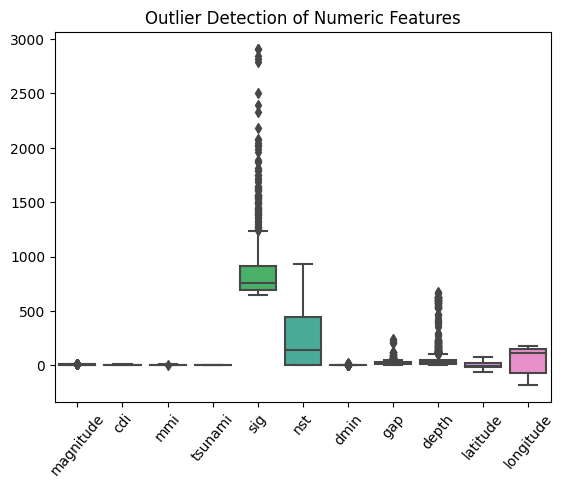

In [100]:
# Outlier Detection helps prevent extreme values from distorting statistical analysis and model predictions
numeric_df = df.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

# Visualize the distribution of outliers 
sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

In [101]:
# Date formatting: The date_time column is an object type, convert it to datetime:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
print(df['date_time'].head())

0   2022-11-22 02:03:00
1   2022-11-18 13:37:00
2   2022-11-12 07:09:00
3   2022-11-11 10:48:00
4   2022-11-09 10:14:00
Name: date_time, dtype: datetime64[ns]


In [102]:
# Clean object columns by removing spaces and converting to lowercase
object_columns = df.select_dtypes(include=['object']).columns
for column in object_columns:
    df[column] = df[column].str.strip().str.replace(' ', '').str.lower()
print(df.head())

                                 title  magnitude           date_time  cdi  \
0  m7.0-18kmswofmalango,solomonislands        7.0 2022-11-22 02:03:00    8   
1     m6.9-204kmswofbengkulu,indonesia        6.9 2022-11-18 13:37:00    4   
2                                m7.0-        7.0 2022-11-12 07:09:00    3   
3          m7.3-205kmeseofneiafu,tonga        7.3 2022-11-11 10:48:00    5   
4                                m6.6-        6.6 2022-11-09 10:14:00    0   

   mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  latitude  \
0    7  green        1  768  us  117  0.509  17.0     mww   14.000   -9.7963   
1    4  green        0  735  us   99  2.229  34.0     mww   25.000   -4.9559   
2    3  green        1  755  us  147  3.125  18.0     mww  579.000  -20.0508   
3    5  green        1  833  us  149  1.865  21.0     mww   37.000  -19.2918   
4    2  green        1  670  us  131  4.998  27.0     mww  624.464  -25.5948   

   longitude                location continent    

In [103]:
# EDA the target variable 

Target Class Distribution:
tsunami
0    478
1    304
Name: count, dtype: int64

Target Class Distribution (Percentage):
tsunami
0    0.611253
1    0.388747
Name: proportion, dtype: float64


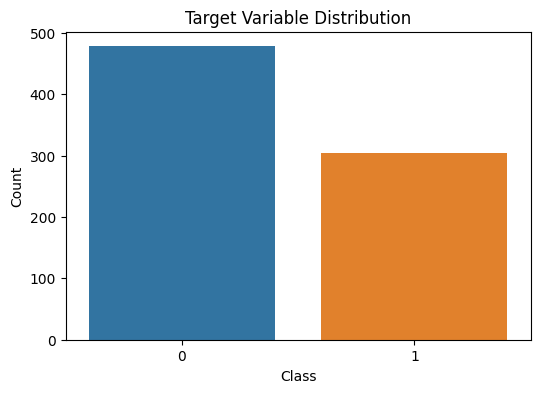

In [104]:
# Step 1: Target Class Distribution
print("Target Class Distribution:")
print(df['tsunami'].value_counts())
print("\nTarget Class Distribution (Percentage):")
print(df['tsunami'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='tsunami', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


Grouped Mean Statistics (Numerical Features):
         magnitude       cdi       mmi  tsunami         sig         nst  \
tsunami                                                                   
0         6.942803  3.928870  6.135983      0.0  874.092050  349.933054   
1         6.938487  4.970395  5.694079      1.0  863.845395   42.065789   

             dmin        gap      depth  latitude  longitude  
tsunami                                                       
0        0.617095  22.792448  69.667356  6.001553  65.461177  
1        2.440036  28.571382  85.656796 -0.335356  32.401155  


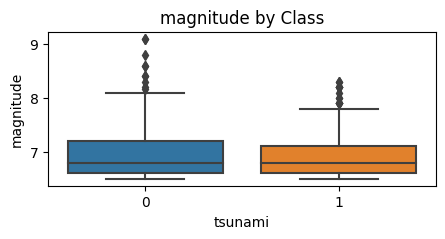

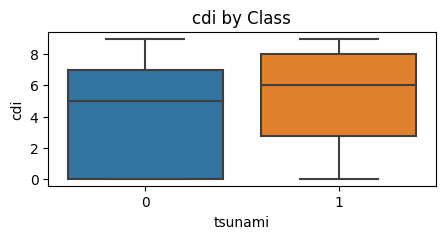

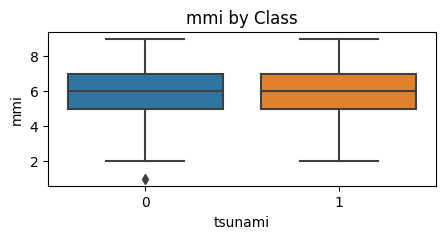

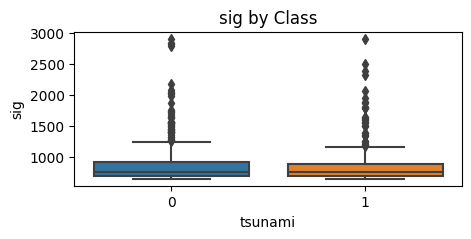

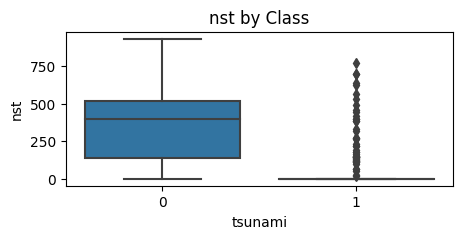

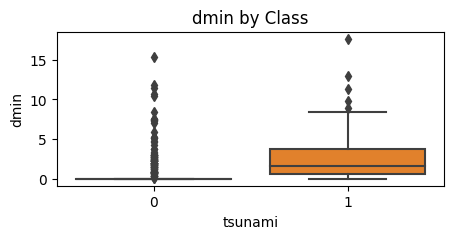

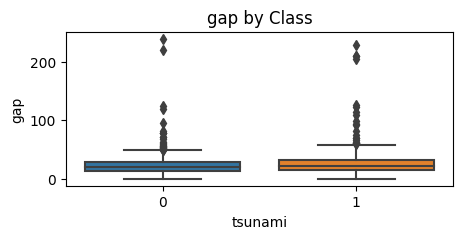

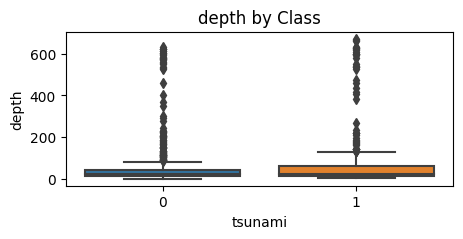

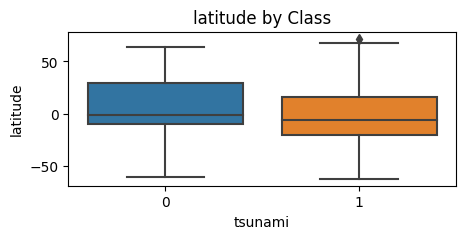

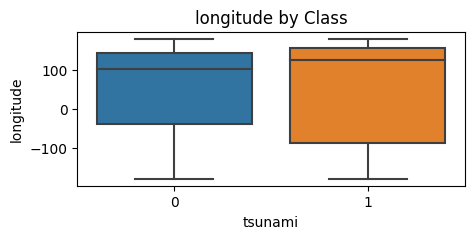

In [105]:
# Step 2: Grouped Mean Statistics
# This step helps decide whether to retain, drop, or transform numerical features based on their correlation with the target.
# Help to find out features should be kept for their potential to differentiate between the target variable class. 

print("\nGrouped Mean Statistics (Numerical Features):")
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
grouped_stats = df.groupby('tsunami')[numeric_columns].mean()
print(grouped_stats)

# Boxplots for numerical features by target class
for column in numeric_columns:
    if column != 'tsunami':  # Exclude the target column itself
        plt.figure(figsize=(5, 2))
        sns.boxplot(x='tsunami', y=column, data=df)
        plt.title(f'{column} by Class')
        plt.show()

Numeric Columns:
 Index(['magnitude', 'cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap',
       'depth', 'latitude', 'longitude'],
      dtype='object')

Correlation with Target Variable 'tsunami':
tsunami      1.000000
dmin         0.400752
cdi          0.160266
gap          0.116360
depth        0.056814
magnitude   -0.004726
sig         -0.015500
latitude    -0.113209
longitude   -0.136778
mmi         -0.147363
nst         -0.600231
Name: tsunami, dtype: float64


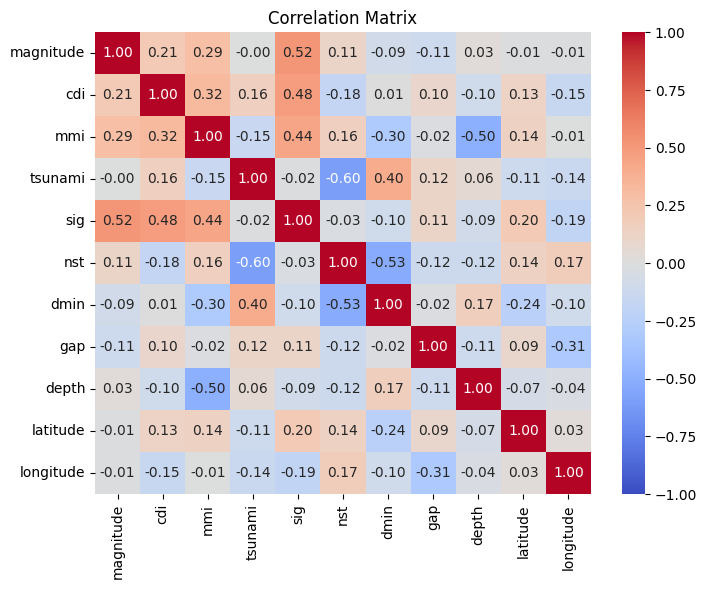

In [106]:
# Step 3: Target-Oriented Correlation Analysis
# This step helps identify the relationship between features and the target variable, 
# Shows which features have strong correlations with the target, suggesting they are useful for prediction.
# Feature Selection: Features with weak or no correlation with the target may be dropped.

# Step: Select numeric columns only
numeric_columns = df.select_dtypes(include=['number'])
print("Numeric Columns:\n", numeric_columns.columns)

# Step: Compute correlation matrix
correlation = numeric_columns.corr()

# Step: Display correlation with the target variable 'tsunami'
print("\nCorrelation with Target Variable 'tsunami':")
print(correlation['tsunami'].sort_values(ascending=False))

# Optional: Visualize the correlation matrix using heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()



Proportions for Categorical Features by Target Class:

title Proportions by Target Class:

alert Proportions by Target Class:
alert   tsunami
green   1          0.744615
        0          0.255385
orange  0          0.500000
        1          0.500000
red     0          0.583333
        1          0.416667
yellow  1          0.732143
        0          0.267857
Name: proportion, dtype: float64

net Proportions by Target Class:

magType Proportions by Target Class:
magType  tsunami
mb       0          1.000000
md       0          1.000000
mi       1          1.000000
ml       0          1.000000
ms       0          1.000000
mw       0          0.687500
         1          0.312500
mwb      0          0.971429
         1          0.028571
mwc      0          1.000000
mww      1          0.626068
         0          0.373932
Name: proportion, dtype: float64

location Proportions by Target Class:

continent Proportions by Target Class:
continent     tsunami
africa        0          1.00

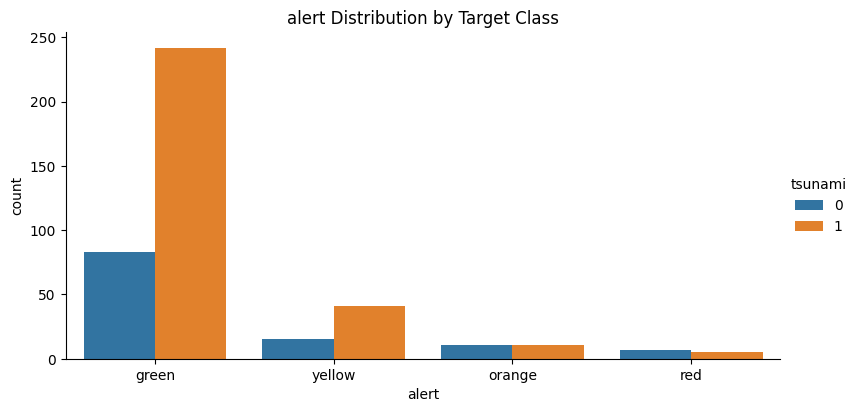

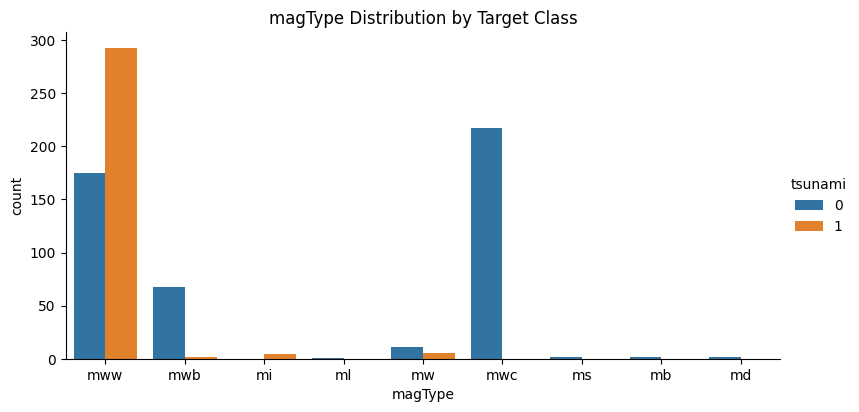

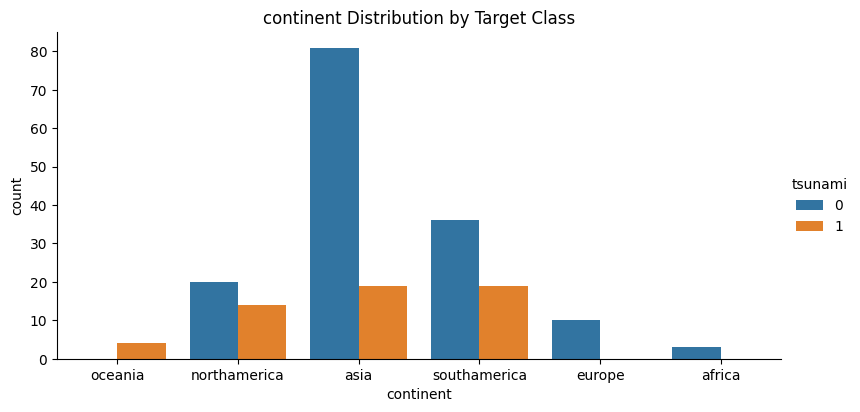

In [107]:
# Step 4: Categorical Features Analysis Vs Target 
# The goal of analyzing categorical features by their proportions with the target is 
# to identify if the features provide meaningful information to predict the target variable.

categorical_columns = df.select_dtypes(include=['object']).columns
print("\nProportions for Categorical Features by Target Class:")
for column in categorical_columns:
    print(f"\n{column} Proportions by Target Class:")
    if df[column].nunique() <= 10:  # Limit for readability
        print(df.groupby(column)['tsunami'].value_counts(normalize=True))

# Visualize categorical distributions
for column in categorical_columns:
    if df[column].nunique() <= 10:  # Visualize only manageable unique values
        sns.catplot(x=column, hue='tsunami', data=df, kind='count', height=4, aspect=2)
        plt.title(f'{column} Distribution by Target Class')
        plt.show()

In [108]:
# Step 5: Check Missing Values in Target
print("\nMissing and Unique Values in Target Variable:")
print(f"Missing Values in 'tsunami': {df['tsunami'].isnull().sum()}")
print(f"Unique Values in 'tsunami': {df['tsunami'].unique()}")


Missing and Unique Values in Target Variable:
Missing Values in 'tsunami': 0
Unique Values in 'tsunami': [1 0]


In [109]:
# Group columns by their data types
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())


object columns:
['title', 'alert', 'net', 'magType', 'location', 'continent', 'country']

float64 columns:
['magnitude', 'dmin', 'gap', 'depth', 'latitude', 'longitude']

datetime64[ns] columns:
['date_time']

int64 columns:
['cdi', 'mmi', 'tsunami', 'sig', 'nst']


## 3. Splitting Data into Training and Test Sets

In [194]:
# Define features (X) and target (y)
# Numerical Features to Drop: magnitude, sig, nst 
# (low correlation with tsunami).
# Categorical Features to Drop: title, date_time, location, continent, country 
# (due to missing values and low relevance).

drop_columns = ['magnitude', 'sig', 'nst', 'title', 'location', 'net', 'date_time', 'country', 'continent']  
x = df.drop(columns=drop_columns + ['tsunami'])  
y = df['tsunami']  

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Print shapes and preview
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")
print(x_train.head())
print(x_train.dtypes)

x_train: (625, 9), y_train: (625,)
x_test: (157, 9), y_test: (157,)
     cdi  mmi  alert   dmin   gap magType  depth  latitude  longitude
602    8    8    NaN  0.000  16.7     mwc  12.00   37.5350    138.446
133    0    5  green  7.568  18.0     mww  38.00  -58.6262    -25.304
239    5    6  green  0.698  21.0     mww  19.00  -37.3586    179.146
55     5    4  green  1.173  36.0     mww  20.74   55.2657   -157.680
613    8    7    NaN  0.000  29.1     mwb  10.00   21.7990    120.547
cdi            int64
mmi            int64
alert         object
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
dtype: object


## 4. Data Preprocessing

In [195]:
# # ??? Turn off means No handle 0 values, 89%
# # ??? Handle 0 values, 84% 

# # select columns with 0 values
# columns_0_as_missing = [col for col in x_train.columns if (x_train[col] == 0).any()]

# # Replace 0 with NaN in those columns
# x_train[columns_0_as_missing] = x_train[columns_0_as_missing].replace(0, np.nan)
# x_test[columns_0_as_missing] = x_test[columns_0_as_missing].replace(0, np.nan)

# # Verify the changes
# print(f"Columns treated as missing:\n{columns_0_as_missing}")
# print(f"Updated Training Data:\n{x_train[columns_0_as_missing].head()}")

In [196]:
# SimpleImputer for numerical_columns
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_imputer = SimpleImputer(strategy='median')
x_train[numerical_columns] = numerical_imputer.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = numerical_imputer.transform(x_test[numerical_columns])
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     cdi  mmi  alert   dmin   gap magType  depth  latitude  longitude
602  8.0  8.0    NaN  0.000  16.7     mwc  12.00   37.5350    138.446
133  0.0  5.0  green  7.568  18.0     mww  38.00  -58.6262    -25.304
239  5.0  6.0  green  0.698  21.0     mww  19.00  -37.3586    179.146
55   5.0  4.0  green  1.173  36.0     mww  20.74   55.2657   -157.680
613  8.0  7.0    NaN  0.000  29.1     mwb  10.00   21.7990    120.547


In [197]:
# Handle Outliers by using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(x_train, col)
    cap_outliers(x_test, col)
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     cdi  mmi  alert   dmin   gap magType  depth  latitude  longitude
602  8.0  8.0    NaN  0.000  16.7     mwc  12.00   37.5350    138.446
133  0.0  5.0  green  4.540  18.0     mww  38.00  -58.6262    -25.304
239  5.0  6.0  green  0.698  21.0     mww  19.00  -37.3586    179.146
55   5.0  4.0  green  1.173  36.0     mww  20.74   55.2657   -157.680
613  8.0  7.0    NaN  0.000  29.1     mwb  10.00   21.7990    120.547


In [198]:
scaler_robust = RobustScaler()
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
x_train[numerical_columns] = scaler_robust.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler_robust.transform(x_test[numerical_columns])
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
          cdi  mmi  alert      dmin       gap magType     depth  latitude  \
602  0.428571  1.0    NaN  0.000000 -0.191083     mwc -0.373692  1.049037   
133 -0.714286 -0.5  green  2.500000 -0.108280     mww  0.274041 -1.408192   
239  0.000000  0.0  green  0.384361  0.082803     mww -0.199302 -0.864737   
55   0.000000 -1.0  green  0.645925  1.038217     mww -0.155954  1.502113   
613  0.428571  0.5    NaN  0.000000  0.598726     mwb -0.423518  0.646931   

     longitude  
602   0.081600  
133  -0.662681  
239   0.266591  
55   -1.264360  
613   0.000245  


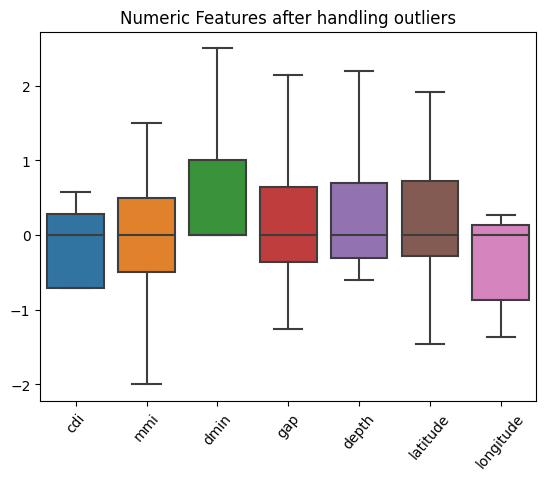

In [199]:
# Plot Numeric features after handling outliers
sns.boxplot(data=x_train[numerical_columns])
plt.title("Numeric Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

In [200]:
print(x_train.dtypes)

cdi          float64
mmi          float64
alert         object
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
dtype: object


In [201]:
# SimpleImputer for object_columns
object_columns = x_train.select_dtypes(include=['object']).columns.tolist()
object_imputer = SimpleImputer(strategy='most_frequent')
x_train[object_columns] = object_imputer.fit_transform(x_train[object_columns])
x_test[object_columns] = object_imputer.transform(x_test[object_columns])
# Check for any missing values after imputation
print(x_train[object_columns].isnull().sum())
print(x_test[object_columns].isnull().sum())
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

alert      0
magType    0
dtype: int64
alert      0
magType    0
dtype: int64
Preprocessed Training set:
          cdi  mmi  alert      dmin       gap magType     depth  latitude  \
602  0.428571  1.0  green  0.000000 -0.191083     mwc -0.373692  1.049037   
133 -0.714286 -0.5  green  2.500000 -0.108280     mww  0.274041 -1.408192   
239  0.000000  0.0  green  0.384361  0.082803     mww -0.199302 -0.864737   
55   0.000000 -1.0  green  0.645925  1.038217     mww -0.155954  1.502113   
613  0.428571  0.5  green  0.000000  0.598726     mwb -0.423518  0.646931   

     longitude  
602   0.081600  
133  -0.662681  
239   0.266591  
55   -1.264360  
613   0.000245  


In [202]:
# # OrdinalEncoder for object_columns
# # Define the ordered categories for 'alert'
# order_columns = ['green', 'yellow', 'orange', 'red']
# ordinal_encoder = OrdinalEncoder(categories=[order_columns])
# x_train['alert'] = ordinal_encoder.fit_transform(x_train[['alert']])
# x_test['alert'] = ordinal_encoder.transform(x_test[['alert']])
# # Verify the changes
# print(f"Preprocessed Training set:\n{x_train.head()}")

In [203]:
# # LabelEncoder for object_columns
# LabelEncoder_columns = ['alert']
# label_encoder = LabelEncoder()
# for col in LabelEncoder_columns:
#     x_train[col] = label_encoder.fit_transform(x_train[col])
#     x_test[col] = label_encoder.transform(x_test[col])
# # Verify the changes
# print(f"Preprocessed Training set:\n{x_train.head()}")

In [204]:
# OneHotEncoder for object_columns
Onehot_encoder_columns = ['alert', 'magType']
Onehot_encoder = OneHotEncoder(sparse_output=False)

# Apply OneHotEncoder to each column
for col in Onehot_encoder_columns:
    transformed_train = Onehot_encoder.fit_transform(x_train[[col]])
    transformed_test = Onehot_encoder.transform(x_test[[col]])
    
    # Create new column names for the one-hot encoded variables
    column_names = [f"{col}_{category}" for category in Onehot_encoder.categories_[0]]
    
    # Add the one-hot encoded columns to the datasets
    x_train = pd.concat([x_train, pd.DataFrame(transformed_train, columns=column_names, index=x_train.index)], axis=1)
    x_test = pd.concat([x_test, pd.DataFrame(transformed_test, columns=column_names, index=x_test.index)], axis=1)
    
    # Drop the original column
    x_train.drop(columns=[col], inplace=True)
    x_test.drop(columns=[col], inplace=True)

# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")
print(f"Preprocessed Test set:\n{x_test.head()}")


Preprocessed Training set:
          cdi  mmi      dmin       gap     depth  latitude  longitude  \
602  0.428571  1.0  0.000000 -0.191083 -0.373692  1.049037   0.081600   
133 -0.714286 -0.5  2.500000 -0.108280  0.274041 -1.408192  -0.662681   
239  0.000000  0.0  0.384361  0.082803 -0.199302 -0.864737   0.266591   
55   0.000000 -1.0  0.645925  1.038217 -0.155954  1.502113  -1.264360   
613  0.428571  0.5  0.000000  0.598726 -0.423518  0.646931   0.000245   

     alert_green  alert_orange  alert_red  alert_yellow  magType_Mi  \
602          1.0           0.0        0.0           0.0         0.0   
133          1.0           0.0        0.0           0.0         0.0   
239          1.0           0.0        0.0           0.0         0.0   
55           1.0           0.0        0.0           0.0         0.0   
613          1.0           0.0        0.0           0.0         0.0   

     magType_mb  magType_md  magType_ml  magType_ms  magType_mw  magType_mwb  \
602         0.0         0.0

In [205]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

# Verify the class distribution
print(y_train_balanced.value_counts())


tsunami
0    387
1    387
Name: count, dtype: int64


In [206]:
print(x_train.dtypes)

cdi             float64
mmi             float64
dmin            float64
gap             float64
depth           float64
latitude        float64
longitude       float64
alert_green     float64
alert_orange    float64
alert_red       float64
alert_yellow    float64
magType_Mi      float64
magType_mb      float64
magType_md      float64
magType_ml      float64
magType_ms      float64
magType_mw      float64
magType_mwb     float64
magType_mwc     float64
magType_mww     float64
dtype: object


## 5. Model Fitting, Test, Evaluation  

In [207]:
model = GaussianNB()
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(f"Accuracy: Model {model} testing dataset: {accuracy:.2f}")


Accuracy: Model GaussianNB() testing dataset: 0.78


In [208]:
model = GaussianNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: Model {model}:")
print(cm)

print(f"Classification Report: Model {model}: ")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: Model {model}: {accuracy:.4f}")

cv_scores = cross_val_score(model, x_train, y_train, cv=5)
print(f"Cross-validation scores: Model {model}:{cv_scores}")
print(f"Average cross-validation score: Model {model}: {cv_scores.mean():.2f}")


Confusion Matrix: Model GaussianNB():
[[60 31]
 [ 3 63]]
Classification Report: Model GaussianNB(): 
              precision    recall  f1-score   support

           0       0.95      0.66      0.78        91
           1       0.67      0.95      0.79        66

    accuracy                           0.78       157
   macro avg       0.81      0.81      0.78       157
weighted avg       0.83      0.78      0.78       157

Accuracy: Model GaussianNB(): 0.7834
Cross-validation scores: Model GaussianNB():[0.76  0.784 0.72  0.744 0.76 ]
Average cross-validation score: Model GaussianNB(): 0.75


In [209]:
# Confusion Matrix for Model GaussianNB()
# True Positives (TP): Correctly predicted class 1 = 57
# True Negatives (TN): Correctly predicted class 0 = 70
# False Positives (FP): Class 0 predicted as class 1 = 21
# False Negatives (FN): Class 1 predicted as class 0 = 9

# Classification Report:
# - Precision: How many predicted positives are correct
#   - Class 0: 0.89, Class 1: 0.73
# - Recall: How many actual positives are correctly identified
#   - Class 0: 0.77, Class 1: 0.86
# - F1-Score: Balance of precision and recall
#   - Class 0: 0.82, Class 1: 0.79
# - Accuracy: Overall correctness of predictions = 80.89%

# - Macro avg: Average of precision, recall, F1 across both classes (0.81, 0.82, 0.81)
# - Weighted avg: Weighted average of precision, recall, F1 across both classes (0.82, 0.81, 0.81)

# Cross-validation scores: [0.848, 0.824, 0.808, 0.776, 0.84]
# - Average cross-validation score: 0.82, showing consistent performance across data splits


# 6. Evaluation models

In [210]:
# Define models
models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
}

# Train and evaluate each model
for name, model in models.items():
    print(f"Evaluating model: {name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:")
    print(cm)
    
    # Classification report
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy:.4f}")
    
    # Cross-validation scores
    cv_scores = cross_val_score(model, x_train, y_train, cv=5)
    print(f"Cross-validation scores for {name}: {cv_scores}")
    print(f"Average cross-validation score for {name}: {cv_scores.mean():.2f}")
    
    print('-' * 50)


Evaluating model: KNeighborsClassifier
Confusion Matrix for KNeighborsClassifier:
[[77 14]
 [19 47]]
Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        91
           1       0.77      0.71      0.74        66

    accuracy                           0.79       157
   macro avg       0.79      0.78      0.78       157
weighted avg       0.79      0.79      0.79       157

Accuracy for KNeighborsClassifier: 0.7898
Cross-validation scores for KNeighborsClassifier: [0.848 0.808 0.784 0.776 0.744]
Average cross-validation score for KNeighborsClassifier: 0.79
--------------------------------------------------
Evaluating model: DecisionTreeClassifier
Confusion Matrix for DecisionTreeClassifier:
[[84  7]
 [10 56]]
Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        91
           1       0.89

In [211]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [10, 20],  # Maximum depth of each tree
    'class_weight': ['balanced', None]  # Handling class imbalance
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)  
grid_search.fit(x_train, y_train)  

# Display the best parameters from grid search
print(f"Best Parameters: {grid_search.best_params_}")

# Update the model to the best estimator found by grid search
model = grid_search.best_estimator_

# Make predictions with the optimized model
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: Model {model}:")
print(cm)

print(f"\nClassification Report: Model {model}: ")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: Model {model}: {accuracy:.4f}")

cv_scores = cross_val_score(model, x_train, y_train, cv=5)
print(f"Cross-validation scores: Model {model}:{cv_scores}")
print(f"Average cross-validation score: Model {model}: {cv_scores.mean():.2f}")


Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 200}
Confusion Matrix: Model RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       random_state=42):
[[81 10]
 [ 7 59]]

Classification Report: Model RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       random_state=42): 
              precision    recall  f1-score   support

           0       0.92      0.89      0.91        91
           1       0.86      0.89      0.87        66

    accuracy                           0.89       157
   macro avg       0.89      0.89      0.89       157
weighted avg       0.89      0.89      0.89       157

Accuracy: Model RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       random_state=42): 0.8917
Cross-validation scores: Model RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                  

In [212]:
# Purpose: Perform hyperparameter optimization of RandomForestClassifier using RandomizedSearchCV 
# to find the best combination of hyperparameters and optimize model performance.

# Define the parameter grid
param_grid = {
    'n_estimators': np.arange(50, 201, 50),  # Number of trees in the forest
    'max_depth': np.arange(5, 21, 5),  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples required to be at a leaf node
    'class_weight': [None, 'balanced'],  # Handle imbalanced classes
}

# Initialize the RandomForestClassifier
model = RandomForestClassifier()

# Setup the RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(estimator=model, 
                                   param_distributions=param_grid,
                                   n_iter=50,  # Number of random combinations to test
                                   cv=5,  # Cross-validation splitting
                                   verbose=2,  # Print progress
                                   random_state=42, 
                                   n_jobs=-1)  # Use all available cores

# Fit the random search to the data
random_search.fit(x_train, y_train)

# Print the best parameters found by RandomizedSearchCV
print(f"Best Parameters: {random_search.best_params_}")

# Train the model with the best parameters
best_model = random_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(x_test)


cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: Model {model}:")
print(cm)

print(f"Classification Report: Model {model}: ")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: Model {model}: {accuracy:.4f}")

cv_scores = cross_val_score(model, x_train, y_train)
print(f"Cross-validation scores: Model {model}:{cv_scores}")
print(f"Average cross-validation score: Model {model}: {cv_scores.mean():.2f}")



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'class_weight': None}
Confusion Matrix: Model RandomForestClassifier():
[[79 12]
 [ 6 60]]
Classification Report: Model RandomForestClassifier(): 
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        91
           1       0.83      0.91      0.87        66

    accuracy                           0.89       157
   macro avg       0.88      0.89      0.88       157
weighted avg       0.89      0.89      0.89       157

Accuracy: Model RandomForestClassifier(): 0.8854
Cross-validation scores: Model RandomForestClassifier():[0.904 0.92  0.864 0.84  0.904]
Average cross-validation score: Model RandomForestClassifier(): 0.89
